### 서울시 행정동별 요양시설 유효공급 격차 ⑥ 부족 석수

> 검토 정정: 부족 합계는 수요·2024년 중앙값 목표를 고정한 가산적 모형의 격차이며 실제 미충족 입소 수요가 아니다. 2,553석 환산은 q≈0.941을 가정한다. 동 중심점·50석·5km·동일 q·12동 목표의 정수 최적화는 후보당 1곳 26곳, 2곳 23곳이다. 기존 24곳은 순차 배치 해다. 전국 159.8은 총량 비율이며 전국 공간 접근성 중앙값이 아니다.

보고서 문장은 독립 재계산 산출물의 입력 해시가 일치할 때만 표시한다. 자료를 바꾸면 `python 검토_재계산.py`를 실행한다.


접근성 $A_i$(1~2등급 인정자 1명당 닿을 수 있는 유효 정원)가 기준값 $A^*$에 못 미치는 만큼을 동의 수요에 곱해 '부족 석수'로 환산한다.

$$\text{부족 석수}_i = \max(0,\; A^* - A_i) \times D_i$$

### 1. 분석 기준

- $A_i$: 04 노트북과 같은 E2SFCA(주 반경 5km, 민감도 10km, 수요 버전 A, 공급 = 정원 × q). 단위는 유효 정원(정원 × 품질 가중치)이다.
- 기준값 $A^*$ 두 가지
  - **서울 동 중앙값**(서울 내부 형평): 서울 동의 절반이 도달한 수준까지 나머지 동을 끌어올리는 데 필요한 규모를 석수로 환산한다.
  - **전국 기준**: 전국 입소시설 유효 정원 ÷ 전국 65세 이상 1~2등급 인정자. 서울은 모든 동이 이 기준에 못 미치므로 석수로 환산하지 않고 **전국 수준 대비 비율**로만 서술한다.
- 65세 이상 인구 100명 미만 동(재건축 2곳)은 수요가 0에 가까워 부족 석수도 0에 가깝다. 중앙값 계산에서는 제외한다.
- **동별 부족 석수의 합 = 부족을 없애는 데 필요한 유효 정원의 하한.** 보존 성질($\sum_i D_i A_i = \sum_j S_j$) 때문에 새 시설 하나는 전체 $\sum_i D_i A_i$를 정확히 자기 유효 정원만큼 늘린다. 그중 기준 미달 동의 부족을 메우는 데 쓰이는 몫은 그보다 클 수 없으므로(일부는 기준 이상 동이나 서울 밖 동으로 간다), 부족 석수 합계만큼의 유효 정원은 최소한 필요하다. 실제로 필요한 규모는 입지에 따라 이보다 크며, 6절의 시뮬레이션으로 구한다.
- 유효 정원은 실제 정원 × 품질 가중치 q이므로, 실제 정원으로 바꿀 때는 새 시설의 q(서울 평균)로 나눈다.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy.stats import spearmanr

import config as C
import e2sfca as E

pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

plt.rcParams["font.family"] = ["AppleGothic", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

SENS_D0 = 10
NEW_CAPACITY = 50  # 가상 시설 정원
DEMAND_COL = {"A": "D_A", "B": "D_B"}[C.DEMAND_VERSION] + ("3" if C.INCLUDE_GRADE3 else "")
SUPPLY_COL = f"S_{C.Q_METHOD}_{C.UNRATED_Q}"

### 2. 접근성 다시 계산

In [2]:
dong = gpd.read_file(C.OUTPUT_DIR / "행정동_분석범위.gpkg")
demand = pd.read_csv(C.OUTPUT_DIR / "동별_수요.csv", dtype={"행정동코드": str}).set_index("행정동코드")
dong["D"] = demand.loc[dong["행정동코드"], DEMAND_COL].to_numpy()
dong["지역"] = demand.loc[dong["행정동코드"], "지역"].to_numpy()
dong["65세이상"] = demand.loc[dong["행정동코드"], ["65~74세", "75~84세", "85세 이상"]].sum(axis=1).to_numpy()
fac = pd.read_csv(C.OUTPUT_DIR / "시설_공급.csv", dtype={"장기요양기관코드": str})
cached = np.load(C.OUTPUT_DIR / "거리행렬_동x시설.npz", allow_pickle=True)
assert list(cached["dong"]) == list(dong["행정동코드"]) and list(cached["fac"]) == list(fac["장기요양기관코드"])
dist = cached["dist"]

D = dong["D"].to_numpy()
S = fac[SUPPLY_COL].to_numpy()
acc = {}
for d0 in (C.D0_KM, SENS_D0):
    res = E.e2sfca(D, S, dist, d0, C.DECAY)
    E.check_conservation(res, D, S)
    acc[d0] = res.accessibility

seoul = dong["서울"].to_numpy()
eligible = seoul & (dong["65세이상"].to_numpy() >= C.MIN_POP65)

# 04 노트북 결과와 같은지 확인
prev = pd.read_csv(C.OUTPUT_DIR / "동별_접근성.csv", dtype={"행정동코드": str}).set_index("행정동코드")
assert np.allclose(acc[C.D0_KM][seoul] * 100, prev.loc[dong.loc[seoul, "행정동코드"], "A100"].to_numpy())
robust = set(pd.read_csv(C.OUTPUT_DIR / "견고한_우선동.csv", dtype={"행정동코드": str})["행정동코드"])
dong["견고한우선동"] = dong["행정동코드"].isin(robust)
print(f"서울 동 {seoul.sum()}개(중앙값 계산 대상 {eligible.sum()}개), 견고한 우선 동 {len(robust)}곳")

서울 동 426개(중앙값 계산 대상 424개), 견고한 우선 동 12곳


### 3. 기준값 A*

In [3]:
# 전국 기준: 전국 입소시설 유효 정원 ÷ 전국 65세 이상 1~2등급 인정자
q_table = pd.read_csv(C.OUTPUT_DIR / "q_표.csv", index_col=0)[C.Q_METHOD]
evaluation = pd.read_csv(C.EVAL_FILE, encoding="cp949", dtype=str)
evaluation["장기요양기관코드"] = evaluation["장기요양기관기호"].str.replace("-", "", regex=False)
rating = (
    evaluation.loc[evaluation["평가구분"].eq(C.EVAL_CYCLE) & evaluation["급여종류"].str.match(r"^0[123]\.")]
    .set_index("장기요양기관코드")["평가등급"]
)
capacity = pd.read_excel(C.FACILITY_FILE, sheet_name="입소인원", dtype={"장기요양기관코드": str})
nat = capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES)].groupby("장기요양기관코드")[["정원"]].sum()
nat["등급"] = rating.reindex(nat.index).fillna("미평가").to_numpy()
rated = nat.loc[nat["등급"].ne("미평가")]
nat_mean_q = np.average(rated["등급"].map(q_table), weights=rated["정원"])
nat["q"] = nat["등급"].map(q_table).where(nat["등급"].ne("미평가"), nat_mean_q)

grade_raw = pd.read_csv(C.GRADE_FILE, encoding="cp949")
grade_raw.columns = [c.strip() for c in grade_raw.columns]
g12 = sum(pd.to_numeric(grade_raw[c].astype(str).str.replace(",", "", regex=False)) for c in ["1등급", "2등급"])
is65 = ~grade_raw["연령구분"].astype(str).str.strip().eq("65세미만")
nat_g12_65, nat_g12_all = g12[is65].sum(), g12.sum()

A_STAR = {
    "서울 동 중앙값": {d0: float(np.median(acc[d0][eligible])) for d0 in acc},
    "전국 기준": {d0: float((nat["정원"] * nat["q"]).sum() / nat_g12_65) for d0 in acc},
}
nat_simple = nat["정원"].sum() / nat_g12_all
star_table = pd.DataFrame({
    f"반경 {d0}km": {name: v[d0] * 100 for name, v in A_STAR.items()} for d0 in acc
})
star_table.loc["(참고) 전국 정원 ÷ 전국 1~2등급 인정자"] = nat_simple * 100
display(Markdown("**기준값 A\\* (1~2등급 인정자 100명당 유효 정원, 석)**"))
display(star_table.style.format("{:.1f}"))
share_below = (acc[C.D0_KM][eligible] < A_STAR["전국 기준"][C.D0_KM]).mean()
nat_resident = capacity.loc[capacity["기관유형코드"].isin(C.RESIDENTIAL_CODES), "현원"].sum()
min_non12 = nat_resident - nat_g12_all
median_ratio = {d0: A_STAR["서울 동 중앙값"][d0] / A_STAR["전국 기준"][d0] for d0 in acc}
display(Markdown(
    f"- 서울 동 중앙값은 전국 수준의 **{median_ratio[C.D0_KM]:.0%}**(반경 {C.D0_KM}km), {median_ratio[SENS_D0]:.0%}(반경 {SENS_D0}km)다.\n"
    f"- 전국 값이 1명당 1석을 넘는 이유: 전국 입소시설 현원 {nat_resident:,}명이 전 연령 1~2등급 인정자 {nat_g12_all:,}명보다 많다. "
    f"1~2등급 인정자가 모두 시설에 산다고 가정해도 현원의 최소 {min_non12 / nat_resident:.0%}({min_non12:,}명)는 3등급 이하 인정자다.\n"
    f"- 전국: 입소 정원 {nat['정원'].sum():,.0f}석(유효 {(nat['정원'] * nat['q']).sum():,.0f}석), "
    f"65세 이상 1~2등급 인정자 {nat_g12_65:,}명 (전 연령 {nat_g12_all:,}명)\\n"
    f"- 반경 {C.D0_KM}km에서 전국 기준에 못 미치는 서울 동: {share_below:.0%}\\n"
    f"- 수요를 1~2등급으로 좁게 잡았으므로 기준값도 같은 분모로 맞췄다."
))

**기준값 A\* (1~2등급 인정자 100명당 유효 정원, 석)**

,반경 5km,반경 10km
서울 동 중앙값,67.5,77.7
전국 기준,159.8,159.8
(참고) 전국 정원 ÷ 전국 1~2등급 인정자,161.3,161.3


- 서울 동 중앙값은 전국 수준의 **42%**(반경 5km), 49%(반경 10km)다.
- 전국 값이 1명당 1석을 넘는 이유: 전국 입소시설 현원 201,066명이 전 연령 1~2등급 인정자 152,551명보다 많다. 1~2등급 인정자가 모두 시설에 산다고 가정해도 현원의 최소 24%(48,515명)는 3등급 이하 인정자다.
- 전국: 입소 정원 246,110석(유효 230,680석), 65세 이상 1~2등급 인정자 144,370명 (전 연령 152,551명)\n- 반경 5km에서 전국 기준에 못 미치는 서울 동: 100%\n- 수요를 1~2등급으로 좁게 잡았으므로 기준값도 같은 분모로 맞췄다.

### 4. 동별 부족 석수

In [4]:
seoul_q = fac.loc[fac["시도"].eq("서울특별시"), SUPPLY_COL].sum() / fac.loc[fac["시도"].eq("서울특별시"), "정원"].sum()
out = dong.loc[seoul, ["행정동코드", "행정동명", "지역", "D", "65세이상", "견고한우선동", "geometry"]].copy()
out["행정동명"] = out["행정동명"].str.split().str[-1]
for d0 in acc:
    out[f"A100_{d0}km"] = acc[d0][seoul] * 100
    out[f"부족_중앙값_{d0}km"] = E.shortage(acc[d0][seoul], D[seoul], A_STAR["서울 동 중앙값"][d0])
    out[f"전국대비_{d0}km"] = acc[d0][seoul] / A_STAR["전국 기준"][d0]
out["소수요"] = out["65세이상"] < C.MIN_POP65
out.drop(columns="geometry").to_csv(C.OUTPUT_DIR / "동별_부족석수.csv", index=False)

k = C.D0_KM
need = {d0: out[f"부족_중앙값_{d0}km"].sum() for d0 in acc}
summary = pd.DataFrame({
    "부족 동 수": [(out[f"부족_중앙값_{d0}km"] > 0).sum() for d0 in acc],
    "필요 유효 정원 하한": [need[d0] for d0 in acc],
    "실제 정원 환산(÷ 서울 평균 q)": [need[d0] / seoul_q for d0 in acc],
    "견고한 우선 동 부족 합": [out.loc[out["견고한우선동"], f"부족_중앙값_{d0}km"].sum() for d0 in acc],
    "전국 대비 중앙값": [out.loc[~out["소수요"], f"전국대비_{d0}km"].median() for d0 in acc],
    "전국 대비 P90": [out.loc[~out["소수요"], f"전국대비_{d0}km"].quantile(0.9) for d0 in acc],
}, index=[f"반경 {d0}km" for d0 in acc])
display(Markdown(f"**A\* = 서울 동 중앙값. 서울 평균 q = {seoul_q:.3f}**"))
display(summary.style.format({"부족 동 수": "{:,.0f}", "필요 유효 정원 하한": "{:,.0f}", "실제 정원 환산(÷ 서울 평균 q)": "{:,.0f}",
                              "견고한 우선 동 부족 합": "{:,.0f}", "전국 대비 중앙값": "{:.0%}", "전국 대비 P90": "{:.0%}"}))

top = out.nlargest(20, f"부족_중앙값_{k}km")
display(Markdown(f"**부족 석수 상위 20개 동 (A\* = 서울 동 중앙값, 반경 {k}km)**"))
display(
    top[["행정동명", "지역", "D", f"A100_{k}km", f"부족_중앙값_{k}km", f"부족_중앙값_{SENS_D0}km", f"전국대비_{k}km", "견고한우선동"]]
    .rename(columns={"D": "추정 수요", f"A100_{k}km": "100명당 유효 정원", f"부족_중앙값_{k}km": "부족 석수",
                     f"부족_중앙값_{SENS_D0}km": f"부족 석수({SENS_D0}km)", f"전국대비_{k}km": "전국 수준 대비"})
    .style.format({"추정 수요": "{:.0f}", "100명당 유효 정원": "{:.1f}", "부족 석수": "{:.1f}", f"부족 석수({SENS_D0}km)": "{:.1f}", "전국 수준 대비": "{:.0%}"})
    .hide(axis="index")
)

**A\* = 서울 동 중앙값. 서울 평균 q = 0.941**

,부족 동 수,필요 유효 정원 하한,실제 정원 환산(÷ 서울 평균 q),견고한 우선 동 부족 합,전국 대비 중앙값,전국 대비 P90
반경 5km,213,"2,402","2,553",295,42%,69%
반경 10km,213,"1,928","2,049",244,49%,72%


**부족 석수 상위 20개 동 (A\* = 서울 동 중앙값, 반경 5km)**

행정동명,지역,추정 수요,100명당 유효 정원,부족 석수,부족 석수(10km),전국 수준 대비,견고한우선동
여의동,영등포구,102,24.6,43.9,19.2,15%,False
상도1동,동작구,105,27.5,42.2,30.1,17%,False
사당2동,동작구,76,15.8,39.4,29.6,10%,True
이촌1동,용산구,74,18.3,36.2,28.8,11%,True
흑석동,동작구,74,19.0,35.9,25.5,12%,True
노량진1동,동작구,85,25.8,35.3,25.0,16%,False
공덕동,마포구,89,28.4,34.9,25.7,18%,False
압구정동,강남구,77,29.5,29.2,26.7,18%,False
사당3동,동작구,57,17.1,28.8,20.4,11%,True
당산2동,영등포구,66,25.5,27.5,2.8,16%,False


In [5]:
# 민감도: 반경 10km에서 부족 석수 순위가 얼마나 유지되는가
rho_sh = spearmanr(out[f"부족_중앙값_{k}km"], out[f"부족_중앙값_{SENS_D0}km"])[0]
top20_5 = set(out.nlargest(20, f"부족_중앙값_{k}km")["행정동코드"])
top20_10 = set(out.nlargest(20, f"부족_중앙값_{SENS_D0}km")["행정동코드"])
robust_in_top = out.loc[out["견고한우선동"] & out["행정동코드"].isin(top20_5)]
display(Markdown(
    f"- 반경 {k}km와 {SENS_D0}km의 부족 석수 순위 상관: {rho_sh:.2f}, 상위 20개 동 겹침: {len(top20_5 & top20_10)}곳\n"
    f"- 견고한 우선 동 {len(robust)}곳 중 반경 {k}km 부족 석수 상위 20위 안: {len(robust_in_top)}곳"
))

- 반경 5km와 10km의 부족 석수 순위 상관: 0.83, 상위 20개 동 겹침: 10곳
- 견고한 우선 동 12곳 중 반경 5km 부족 석수 상위 20위 안: 6곳

### 5. 지도

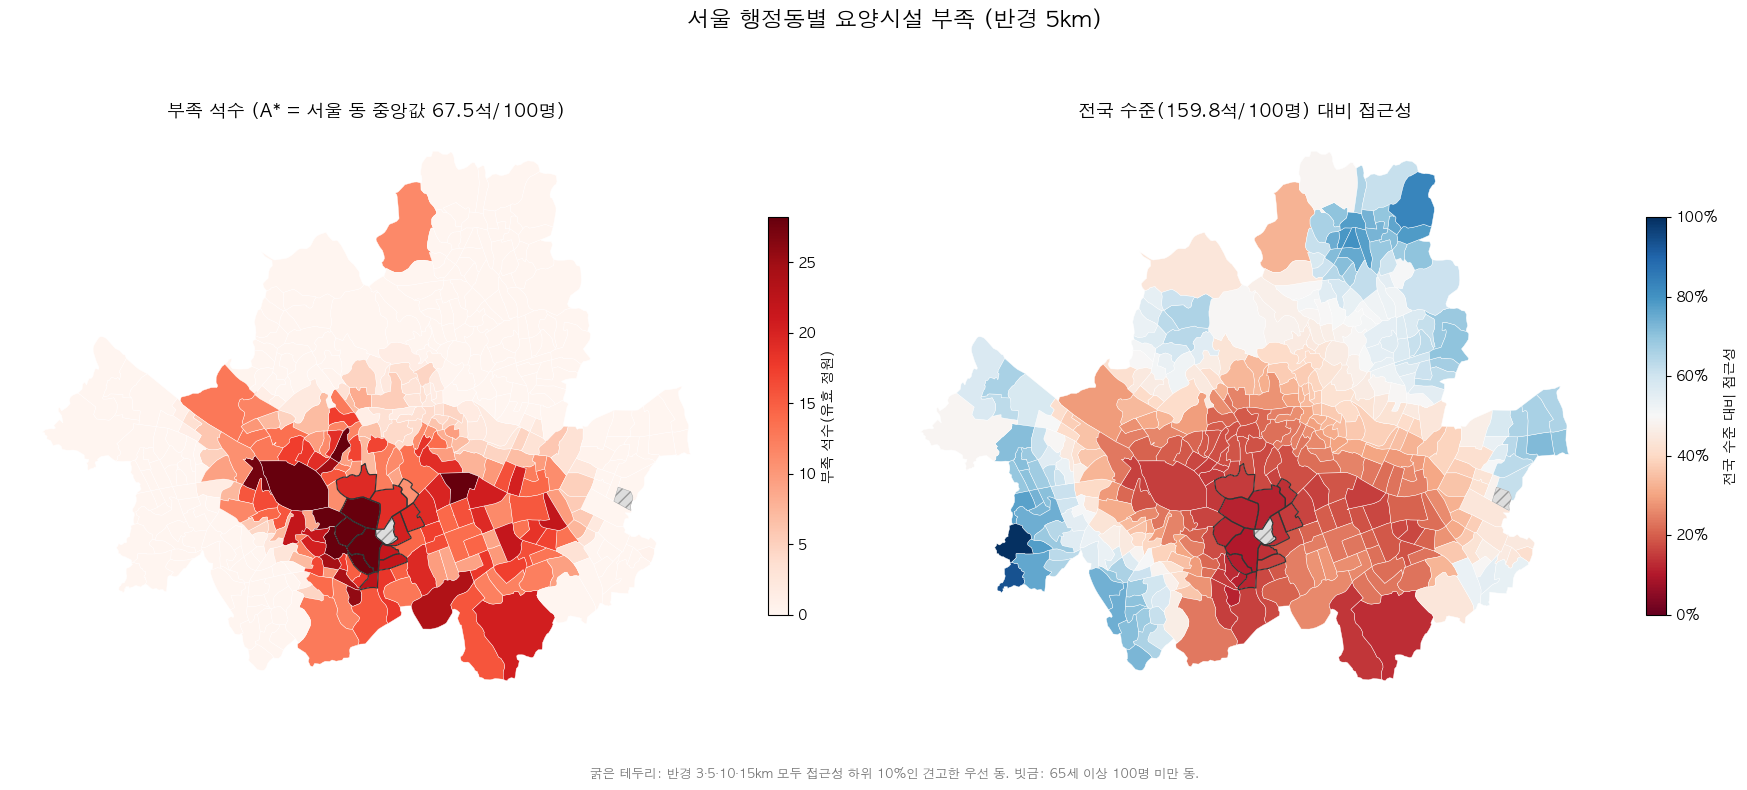

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
col = f"부족_중앙값_{k}km"
out.plot(column=col, ax=axes[0], cmap="Reds", vmin=0, vmax=out[col].quantile(0.98), edgecolor="white", linewidth=0.3,
         legend=True, legend_kwds={"shrink": 0.6, "label": "부족 석수(유효 정원)"})
axes[0].set_title(f"부족 석수 (A* = 서울 동 중앙값 {A_STAR['서울 동 중앙값'][k] * 100:.1f}석/100명)", fontsize=13)
col = f"전국대비_{k}km"
out.plot(column=col, ax=axes[1], cmap="RdBu", vmin=0, vmax=1, edgecolor="white", linewidth=0.3,
         legend=True, legend_kwds={"shrink": 0.6, "label": "전국 수준 대비 접근성", "format": lambda x, _: f"{x:.0%}"})
axes[1].set_title(f"전국 수준({A_STAR['전국 기준'][k] * 100:.1f}석/100명) 대비 접근성", fontsize=13)
for ax in axes:
    out.loc[out["소수요"]].plot(ax=ax, color="#DDDDDD", edgecolor="#999999", hatch="///", linewidth=0.3)
    out.loc[out["견고한우선동"]].boundary.plot(ax=ax, color="#333333", linewidth=0.9)
    ax.set_axis_off()
fig.suptitle(f"서울 행정동별 요양시설 부족 (반경 {k}km)", fontsize=16)
fig.text(0.5, 0.02, "굵은 테두리: 반경 3·5·10·15km 모두 접근성 하위 10%인 견고한 우선 동. 빗금: 65세 이상 100명 미만 동.",
         ha="center", fontsize=9, color="#777777")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(C.OUTPUT_DIR / "부족석수_지도.png", dpi=200, bbox_inches="tight")
plt.show()

### 6. 시뮬레이션: 견고한 우선 동을 서울 중앙값까지

후보지(서울 동 중심점)에 가상 시설(정원 50석, 품질은 서울 평균 q)을 추가하고 E2SFCA를 다시 계산한다. 새 시설은 기존 시설의 공급비 $R_j$를 바꾸지 않으므로 $A_i' = A_i + R_{new} W(d_{i,new})$로 정확히 갱신된다(`e2sfca.add_facility`). 기준값은 시뮬레이션 전 서울 동 중앙값으로 고정하고, **견고한 우선 동 12곳이 모두 이 값에 이를 때까지** 시설을 하나씩 추가한다. 후보지는 동마다 한 번만 쓴다.

입지는 **부족분의 제곱 합**($\sum_i D_i (A^* - A_i)_+^2$)을 가장 많이 줄이는 곳부터 고른다(greedy). 선형 기준(부족 석수 합계)은 보존 성질 때문에 새 시설이 Σ D·A를 정확히 자기 유효 정원만큼 늘려, 반경 안 동이 모두 기준 미달로 남는 후보지의 감소량이 모두 새 유효 정원과 같아지므로 입지를 가려내지 못한다.

In [7]:
new_supply = NEW_CAPACITY * seoul_q
a_star = A_STAR["서울 동 중앙값"][k]
cand = dong.loc[eligible, ["행정동코드", "행정동명", "지역", "cx", "cy"]].reset_index(drop=True)
cand["행정동"] = cand["행정동명"].str.split().str[-1]
dist_cand = E.distance_matrix_km(dong[["cx", "cy"]].to_numpy(), cand[["cx", "cy"]].to_numpy())

# 보존 성질 assert: 가상 시설 하나를 추가하면 전체 Σ D·A가 정확히 그 시설의 유효 정원만큼 늘어난다.
j0 = 0
a1 = E.add_facility(acc[k], D, dist_cand[:, j0], new_supply, k, C.DECAY)
assert np.isclose(np.dot(D, a1) - np.dot(D, acc[k]), new_supply)

before_lin = E.shortfall_objective(acc[k][seoul], D[seoul], a_star, "linear")
single = []
for j in range(len(cand)):
    a1 = E.add_facility(acc[k], D, dist_cand[:, j], new_supply, k, C.DECAY)
    single.append(before_lin - E.shortfall_objective(a1[seoul], D[seoul], a_star, "linear"))
n_ties = int((np.array(single) >= max(single) - 1e-6).sum())
assert abs(max(single) - new_supply) < 1e-6

robust_mask = dong["견고한우선동"].to_numpy()
reach = lambda a: bool((a[robust_mask] >= a_star - 1e-12).all())
chosen, acc_after = E.greedy_sites(acc[k], D, dist_cand, new_supply, k, a_star, seoul,
                                   decay=C.DECAY, objective="squared", unique=True, stop=reach)
rows, acc_step, prev_lin = [], acc[k], before_lin
for n, (j, tot_sq, red_sq, ties) in enumerate(chosen, start=1):
    acc_step = E.add_facility(acc_step, D, dist_cand[:, j], new_supply, k, C.DECAY)
    lin = E.shortfall_objective(acc_step[seoul], D[seoul], a_star, "linear")
    rows.append({"순서": n, "행정동": cand.loc[j, "행정동"], "지역": cand.loc[j, "지역"],
                 "견고한 우선 동": cand.loc[j, "행정동코드"] in robust, "동점 후보": ties,
                 "부족 석수 감소": prev_lin - lin, "남은 부족 석수": lin,
                 "우선 동 도달": int((acc_step[robust_mask] >= a_star - 1e-12).sum())})
    prev_lin = lin
greedy = pd.DataFrame(rows)
greedy.to_csv(C.OUTPUT_DIR / "시뮬레이션_greedy.csv", index=False)
assert greedy["행정동"].is_unique and reach(acc_after)

# 검증: 닫힌 식 갱신 = 시설을 추가해 전체를 다시 계산한 값
extra_dist = np.column_stack([dist_cand[:, j] for j, *_ in chosen])
res_full = E.e2sfca(D, np.concatenate([S, np.full(len(chosen), new_supply)]), np.hstack([dist, extra_dist]), k, C.DECAY)
assert np.allclose(res_full.accessibility, acc_after)

n_fac = len(chosen)
added_eff = n_fac * new_supply
robust_seoul = dong.loc[seoul, "견고한우선동"].to_numpy()
rob_before, rob_after = acc[k][seoul][robust_seoul] * 100, acc_after[seoul][robust_seoul] * 100
display(Markdown(
    f"- 선형 기준으로 단독 감소량이 최대(= 새 유효 정원 {new_supply:.1f}석)인 동점 후보지: {n_ties}곳 → 제곱 기준 사용\n"
    f"- 견고한 우선 동 {robust_mask.sum()}곳이 모두 서울 동 중앙값({a_star * 100:.1f}석/100명)에 이르려면 **{NEW_CAPACITY}석 시설 {n_fac}곳, "
    f"정원 {n_fac * NEW_CAPACITY:,}석**(유효 {added_eff:,.0f}석)이 필요하다.\n"
    f"- 그중 견고한 우선 동 안에 놓인 시설 {greedy['견고한 우선 동'].sum()}곳, 제곱 기준에서 동점이 생긴 단계 {(greedy['동점 후보'] > 1).sum()}번\n"
    f"- 서울 전체 부족 석수(중앙값 기준): {before_lin:,.0f}석 → {greedy['남은 부족 석수'].iloc[-1]:,.0f}석 "
    f"(추가한 유효 정원 {added_eff:,.0f}석 중 {(before_lin - greedy['남은 부족 석수'].iloc[-1]) / added_eff:.0%}가 기준 미달 동의 부족을 메우는 데 쓰임)\n"
    f"- 견고한 우선 동의 100명당 유효 정원: {rob_before.min():.1f}~{rob_before.max():.1f}석 → {rob_after.min():.1f}~{rob_after.max():.1f}석"
))
display(greedy.style.format({"부족 석수 감소": "{:,.1f}", "남은 부족 석수": "{:,.0f}"}).hide(axis="index"))

- 선형 기준으로 단독 감소량이 최대(= 새 유효 정원 47.0석)인 동점 후보지: 26곳 → 제곱 기준 사용
- 견고한 우선 동 12곳이 모두 서울 동 중앙값(67.5석/100명)에 이르려면 **50석 시설 81곳, 정원 4,050석**(유효 3,810석)이 필요하다.
- 그중 견고한 우선 동 안에 놓인 시설 10곳, 제곱 기준에서 동점이 생긴 단계 0번
- 서울 전체 부족 석수(중앙값 기준): 2,402석 → 3석 (추가한 유효 정원 3,810석 중 63%가 기준 미달 동의 부족을 메우는 데 쓰임)
- 견고한 우선 동의 100명당 유효 정원: 15.8~25.0석 → 68.3~77.7석

순서,행정동,지역,견고한 우선 동,동점 후보,부족 석수 감소,남은 부족 석수,우선 동 도달
1,서빙고동,용산구,True,1,47.0,"2,355",0
2,이촌1동,용산구,True,1,47.0,"2,308",0
3,한강로동,용산구,True,1,47.0,"2,261",0
4,방배본동,서초구,True,1,47.0,"2,214",0
5,방배4동,서초구,True,1,47.0,"2,167",0
6,원효로1동,용산구,False,1,47.0,"2,120",0
7,삼성2동,강남구,False,1,47.0,"2,073",0
8,원효로2동,용산구,False,1,47.0,"2,025",0
9,방배2동,서초구,False,1,45.9,"1,980",0
10,삼성1동,강남구,False,1,47.0,"1,933",0


**비교: 목표를 견고한 우선 동으로 한정.** 위 시뮬레이션은 제곱 부족을 서울 전체 동에 대해 줄이므로, 우선 동보다 다른 부족 동을 먼저 채우기도 한다. 그 결과 우선 동이 모두 중앙값에 이를 즈음에는 서울 전체 부족이 거의 사라진다. 같은 제곱 기준을 견고한 우선 동 12곳에만 걸었을 때 필요한 시설 수를 함께 본다(후보지는 서울 전체 동 중심점).

목표 동,시설 수,정원,유효 정원,추가 후 서울 부족 석수
서울 전체 동,81,"4,050","3,810",3
견고한 우선 동 12곳,26,"1,300","1,223","1,274"


우선 동 한정 시 입지: 서초구 반포2동, 서초구 방배본동, 용산구 서빙고동, 서초구 방배4동, 동작구 사당2동, 용산구 이촌1동, 서초구 반포4동, 서초구 반포3동, 서초구 방배1동, 동작구 흑석동, 동작구 사당3동, 용산구 한강로동, 동작구 사당1동, 용산구 보광동, 동작구 사당4동, 용산구 이촌2동, 동작구 사당5동, 용산구 이태원1동, 서초구 방배2동, 용산구 용산2가동, 용산구 원효로1동, 관악구 남현동, 용산구 남영동, 용산구 이태원2동, 관악구 인헌동, 서초구 잠원동 (그중 견고한 우선 동 안 12곳)

한 동에 두 곳까지 허용하면 우선 동이 모두 중앙값에 이르는 데 24곳(정원 1,200석)이 필요하다 (두 곳이 들어간 동 11곳). 한 곳씩만 허용할 때는 26곳.

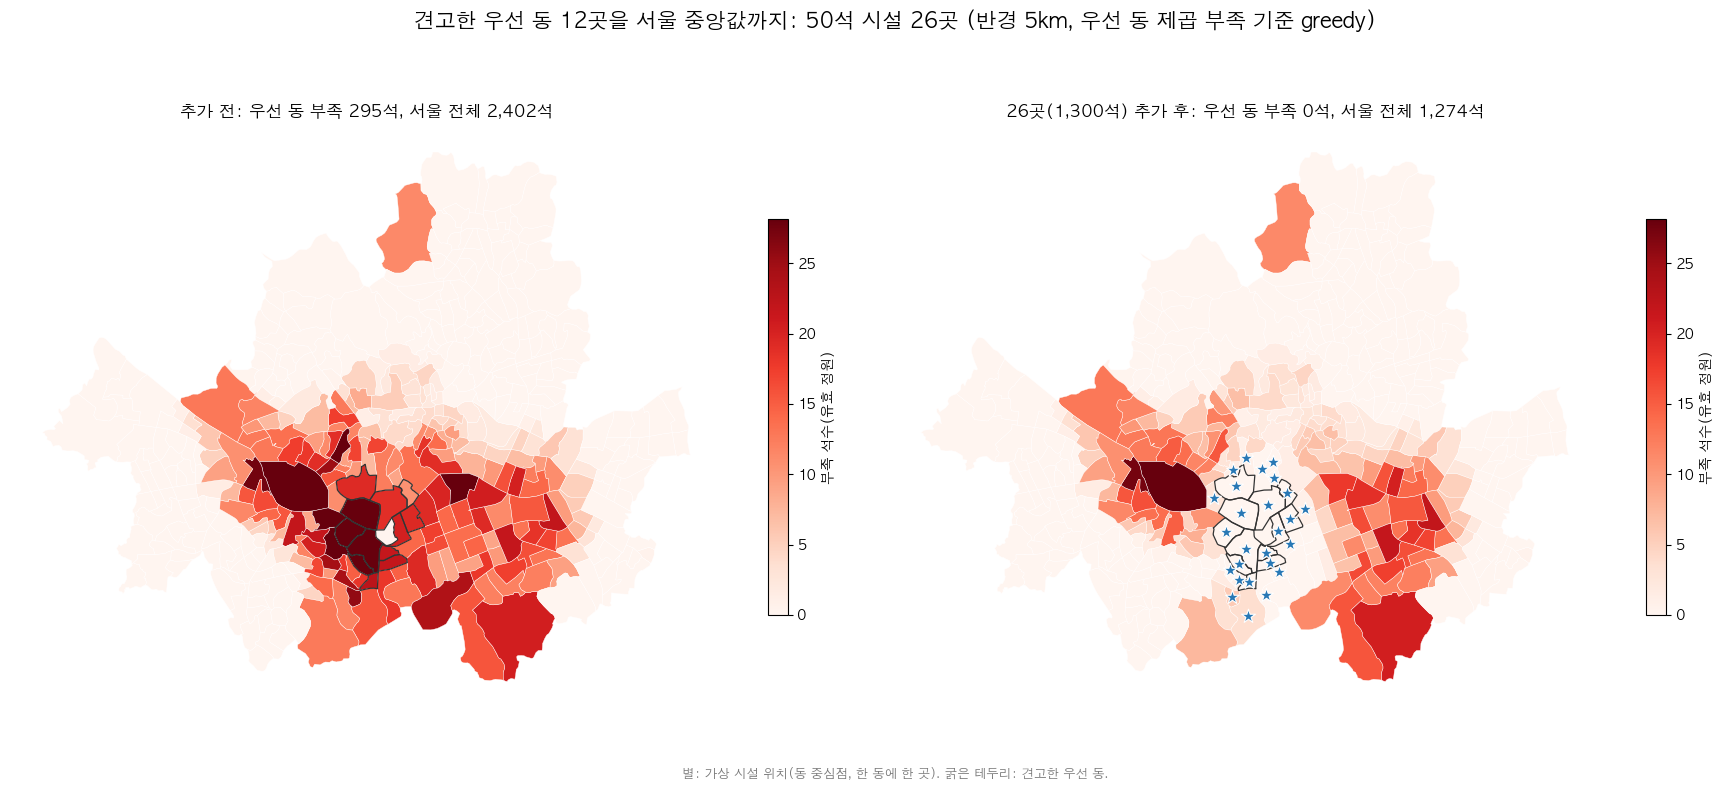

In [8]:
robust_target = dong["견고한우선동"].to_numpy()
chosen_r, acc_after_r = E.greedy_sites(acc[k], D, dist_cand, new_supply, k, a_star, robust_target,
                                       decay=C.DECAY, objective="squared", unique=True, stop=reach)
extra_r = np.column_stack([dist_cand[:, j] for j, *_ in chosen_r])
res_r = E.e2sfca(D, np.concatenate([S, np.full(len(chosen_r), new_supply)]), np.hstack([dist, extra_r]), k, C.DECAY)
assert np.allclose(res_r.accessibility, acc_after_r) and reach(acc_after_r)
n_fac_r = len(chosen_r)
left_r = E.shortfall_objective(acc_after_r[seoul], D[seoul], a_star, "linear")
sites_r = cand.loc[[j for j, *_ in chosen_r]]
compare_sim = pd.DataFrame({
    "목표 동": ["서울 전체 동", "견고한 우선 동 12곳"],
    "시설 수": [n_fac, n_fac_r],
    "정원": [n_fac * NEW_CAPACITY, n_fac_r * NEW_CAPACITY],
    "유효 정원": [n_fac * new_supply, n_fac_r * new_supply],
    "추가 후 서울 부족 석수": [greedy["남은 부족 석수"].iloc[-1], left_r],
})
display(compare_sim.style.format({"정원": "{:,.0f}", "유효 정원": "{:,.0f}", "추가 후 서울 부족 석수": "{:,.0f}"}).hide(axis="index"))
display(Markdown(
    f"우선 동 한정 시 입지: " + ", ".join(f"{r['지역']} {r['행정동']}" for _, r in sites_r.iterrows())
    + f" (그중 견고한 우선 동 안 {sites_r['행정동코드'].isin(robust).sum()}곳)"
))
pd.DataFrame({"순서": range(1, n_fac_r + 1), "행정동": sites_r["행정동"].to_numpy(), "지역": sites_r["지역"].to_numpy()}).to_csv(
    C.OUTPUT_DIR / "시뮬레이션_greedy_우선동한정.csv", index=False)

# 비교: 우선 동 한정, 한 동에 두 곳까지 허용
chosen_r2, acc_after_r2 = E.greedy_sites(acc[k], D, dist_cand, new_supply, k, a_star, robust_target,
                                         decay=C.DECAY, objective="squared", stop=reach, max_per_site=2)
assert reach(acc_after_r2)
n_fac_r2 = len(chosen_r2)
n_double = int((pd.Series([j for j, *_ in chosen_r2]).value_counts() == 2).sum())
display(Markdown(
    f"한 동에 두 곳까지 허용하면 우선 동이 모두 중앙값에 이르는 데 {n_fac_r2}곳(정원 {n_fac_r2 * NEW_CAPACITY:,}석)이 필요하다 "
    f"(두 곳이 들어간 동 {n_double}곳). 한 곳씩만 허용할 때는 {n_fac_r}곳."
))

# 대표 규모(우선 동 한정, 한 동에 한 곳) 전후 지도
out["부족_after_r"] = E.shortage(acc_after_r[seoul], D[seoul], a_star)
vmax = out[f"부족_중앙값_{k}km"].quantile(0.98)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, col, title in ((axes[0], f"부족_중앙값_{k}km", "추가 전"), (axes[1], "부족_after_r", f"{n_fac_r}곳({n_fac_r * NEW_CAPACITY:,}석) 추가 후")):
    out.plot(column=col, ax=ax, cmap="Reds", vmin=0, vmax=vmax, edgecolor="white", linewidth=0.3,
             legend=True, legend_kwds={"shrink": 0.6, "label": "부족 석수(유효 정원)"})
    out.loc[out["견고한우선동"]].boundary.plot(ax=ax, color="#333333", linewidth=0.9)
    ax.set_title(f"{title}: 우선 동 부족 {out.loc[out['견고한우선동'], col].sum():,.0f}석, 서울 전체 {out[col].sum():,.0f}석", fontsize=12)
    ax.set_axis_off()
axes[1].scatter(sites_r["cx"], sites_r["cy"], s=110, marker="*", color="#2878B5", edgecolor="white", linewidth=0.8, zorder=5)
fig.suptitle(f"견고한 우선 동 12곳을 서울 중앙값까지: {NEW_CAPACITY}석 시설 {n_fac_r}곳 (반경 {k}km, 우선 동 제곱 부족 기준 greedy)", fontsize=15)
fig.text(0.5, 0.02, "별: 가상 시설 위치(동 중심점, 한 동에 한 곳). 굵은 테두리: 견고한 우선 동.", ha="center", fontsize=9, color="#777777")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(C.OUTPUT_DIR / "시뮬레이션_전후_지도.png", dpi=200, bbox_inches="tight")
plt.show()

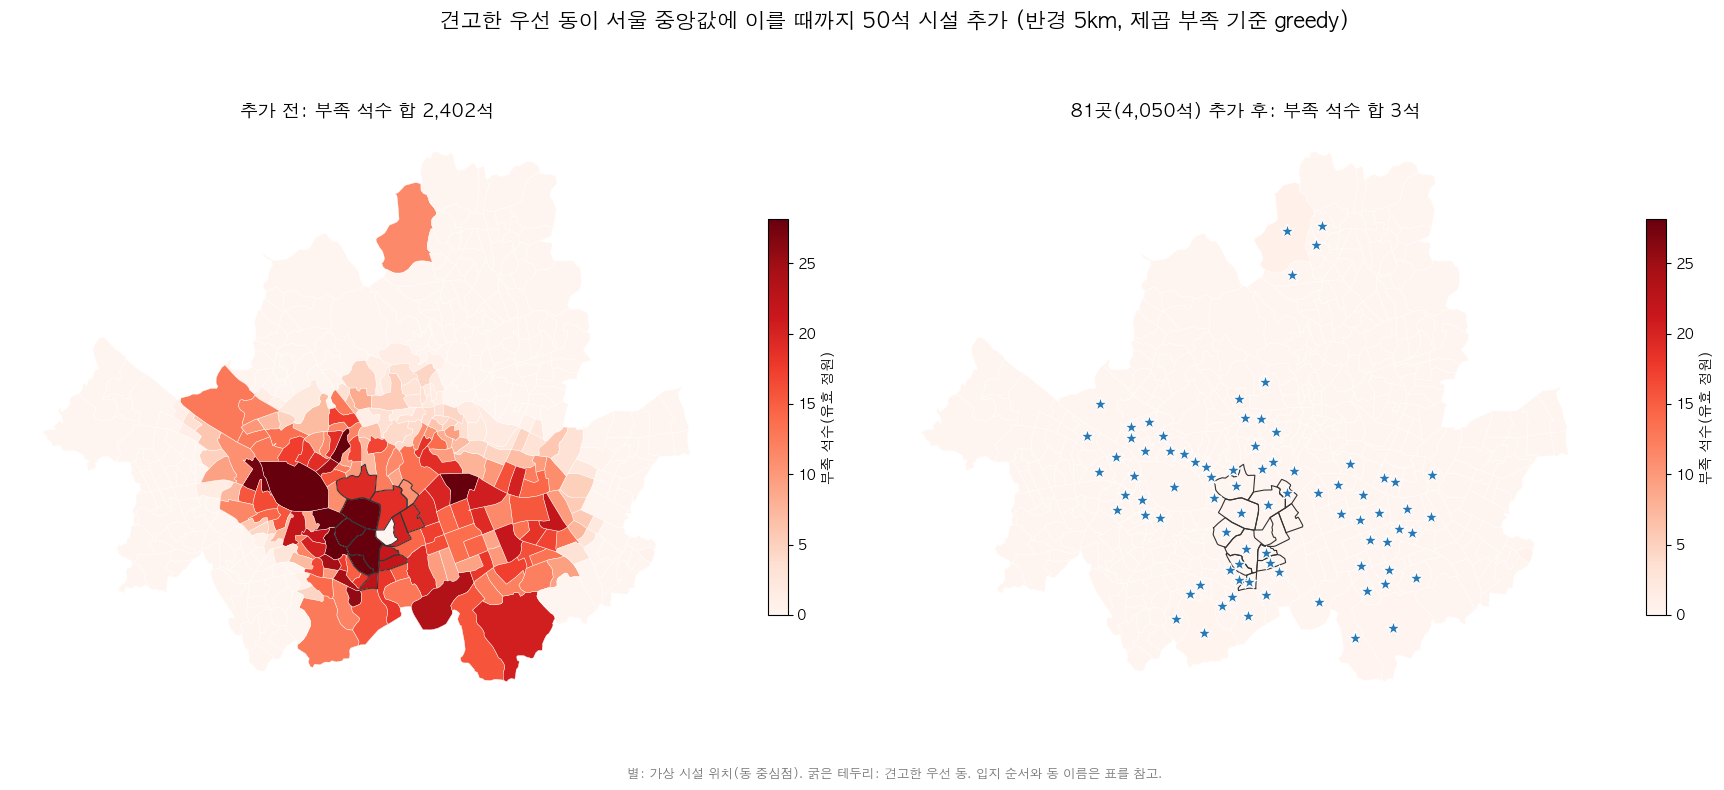

In [9]:
out["부족_after"] = E.shortage(acc_after[seoul], D[seoul], a_star)
sites = cand.loc[[j for j, *_ in chosen]]
vmax = out[f"부족_중앙값_{k}km"].quantile(0.98)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, col, title in ((axes[0], f"부족_중앙값_{k}km", "추가 전"), (axes[1], "부족_after", f"{n_fac}곳({n_fac * NEW_CAPACITY:,}석) 추가 후")):
    out.plot(column=col, ax=ax, cmap="Reds", vmin=0, vmax=vmax, edgecolor="white", linewidth=0.3,
             legend=True, legend_kwds={"shrink": 0.6, "label": "부족 석수(유효 정원)"})
    out.loc[out["견고한우선동"]].boundary.plot(ax=ax, color="#333333", linewidth=0.8)
    ax.set_title(f"{title}: 부족 석수 합 {out[col].sum():,.0f}석", fontsize=13)
    ax.set_axis_off()
axes[1].scatter(sites["cx"], sites["cy"], s=110, marker="*", color="#2878B5", edgecolor="white", linewidth=0.8, zorder=5)
fig.suptitle(f"견고한 우선 동이 서울 중앙값에 이를 때까지 {NEW_CAPACITY}석 시설 추가 (반경 {k}km, 제곱 부족 기준 greedy)", fontsize=15)
fig.text(0.5, 0.02, "별: 가상 시설 위치(동 중심점). 굵은 테두리: 견고한 우선 동. 입지 순서와 동 이름은 표를 참고.",
         ha="center", fontsize=9, color="#777777")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
fig.savefig(C.OUTPUT_DIR / "시뮬레이션_전후_지도_서울전체.png", dpi=200, bbox_inches="tight")
plt.show()

### 7. 보고서 문장

In [ ]:
rob = out.loc[out["견고한우선동"]]


In [1]:
from 검토_재계산 import reviewed_sentences

for sentence in reviewed_sentences("06"):
    print(sentence)


수요와 2024년 서울 중앙값 목표를 고정한 모형상 격차 합계는 유효 정원 2,402석이다. 서울 평균 q=0.940717의 신규 시설을 가정한 물리적 정원 환산 하한은 2,553석이다. 관측된 미충족 입소 수요가 아니다.
서울 424개 동 중심점·5km·50석·동일 q·우선 12동 목표의 정수 최적화: 후보당 1곳이면 최소 26곳(1,300석), 2곳이면 최소 23곳(1,150석)이다. 기존 greedy는 후보당 1곳 26곳 (1,300석), 2곳 24곳 (1,200석)의 순차 배치 해이며 최소로 부르지 않는다. 기존 26곳 지도는 수요가중 제곱 격차를 가장 줄이는 후보 순서로 고른 배치다.
기존 26곳 배치에서 서울 전체 격차는 1,274석, 품질 가중치 개선을 더하면 1,208석이다. 전국 100명당 159.8석은 총유효정원÷전국 65세 이상 인정자라는 총량 비율로, 전국 동 접근성 중앙값과 비교한 것이 아니다.


### 해석상 주의

- 부족 석수는 '유효 정원' 단위다. 정원 환산값은 새 시설이 서울 평균 품질이라고 가정한 값이다. 새 시설의 등급이 높으면 필요한 정원은 줄어든다.
- E2SFCA는 한 사람의 수요를 반경 안 여러 시설이 함께 나눠 받는 구조라, 새 시설이 들어와도 기존 시설의 공급비는 변하지 않는다. 시뮬레이션 결과는 이 가정 아래의 값이다.
- 필요 정원 하한은 기준값을 서울 동 중앙값으로 고정했을 때의 값이다. 새 시설로 접근성이 오르면 중앙값도 오르므로, 목표를 '새 중앙값'으로 두면 필요 규모는 더 커진다.
- 후보지는 동 중심점이다. 실제 부지(공공부지, 용도지역)와 지가는 반영하지 않았다.
- 수요는 현재(2024년 7월) 기준이며, 미래 수요 증가는 6단계에서 다룬다.